### **Program No. 05 : Seven Stages of Data Visualization**

#### Uncleaned_Student_Dataset

Attributes include: `student_id, roll_number, department, program, academic_year, course_code, attendance_percentage, internal_marks, external_marks, sgpa, gender, age, study_hours`

**Note**:
The dataset contains:

- Missing values
- Inconsistent entries (e.g., gender formats, study_hours as text)
- Blank fields
This makes it suitable for explaining the complete visualization workflow.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Data Collection

Data is collected from raw sources without modification.

**Example**:
Student academic and demographic records collected from different departments and stored as `Uncleaned_Student_Dataset`.

In [2]:
df = pd.read_csv('Uncleaned_Student_Dataset.csv')
print(df.head())
print(df.info())

   student_id roll_number department program academic_year course_code  \
0         176        R113        BCA     NaN       2023-24       ML401   
1         197         R28         ME   MTech       2024-25       IT305   
2          26         R16        ECE     MBA       2024-25         NaN   
3          68        R108        CSE     MBA       2022-23       WD210   
4         212         R32      Civil   MTech           NaN         NaN   

   attendance_percentage  internal_marks  external_marks  sgpa  gender   age  \
0                  82.00            22.2            41.6   NaN  Female  18.0   
1                  42.37            37.3            30.8  6.57       M  19.0   
2                  49.78             NaN            63.9  5.54    Male   NaN   
3                  85.46            26.7            53.4  9.64       M  18.0   
4                  92.36             NaN            60.4  6.01  female   NaN   

  study_hours  
0           5  
1         NaN  
2           1  
3         

### 2. Data Cleaning

Incorrect, missing, and inconsistent data is identified and handled.

**Example:**
- Removing or filling missing sgpa values
- Converting gender values like M, Male, female into a standard format
- Replacing text values like five in study_hours with numeric values

In [3]:
# Handle missing values in sgpa
df['sgpa'] = df['sgpa'].fillna(df['sgpa'].mean())
df['course_code'] = df['course_code'].fillna('Unknown')
df['internal_marks'] = df['internal_marks'].fillna(df['internal_marks'].mean())
df['academic_year'] = df['academic_year'].fillna(df['academic_year'].mode())
df['age'] = df['age'].fillna(df['age'].mean())
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].mode())
df['external_marks'] = df['external_marks'].fillna(df['external_marks'].mean())
df['attendance_percentage'] = df['attendance_percentage'].fillna(df['attendance_percentage'].mean())


# Standardize gender values
df['gender'] = df['gender'].str.upper().replace({'FEMALE': 'F', 'MALE': 'M'})

# Convert text study_hours to numeric
study_hours_mapping = {'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'seven': 7}
df['study_hours'] = pd.to_numeric(df['study_hours'], errors='coerce')
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].mean())

print(df.head())
print(df.info())

   student_id roll_number department program academic_year course_code  \
0         176        R113        BCA     NaN       2023-24       ML401   
1         197         R28         ME   MTech       2024-25       IT305   
2          26         R16        ECE     MBA       2024-25     Unknown   
3          68        R108        CSE     MBA       2022-23       WD210   
4         212         R32      Civil   MTech           NaN     Unknown   

   attendance_percentage  internal_marks  external_marks      sgpa gender  \
0                  82.00       22.200000            41.6  6.764545      F   
1                  42.37       37.300000            30.8  6.570000      M   
2                  49.78       35.341129            63.9  5.540000      M   
3                  85.46       26.700000            53.4  9.640000      M   
4                  92.36       35.341129            60.4  6.010000      F   

         age  study_hours  
0  18.000000     5.000000  
1  19.000000     3.898305  
2  21.29

### 3. Data Processing

Cleaned data is organized and transformed into usable form.

**Example**:

- `Calculating total marks = internal + external`
- Categorizing attendance as low, medium, or high
- Creating age groups

In [4]:
# Calculate total marks
df['total_marks'] = df['internal_marks'] + df['external_marks']

# Categorize attendance as low, medium, or high
df['attendance_category'] = pd.cut(df['attendance_percentage'], 
                                    bins=[0, 50, 75, 100], 
                                    labels=['Low', 'Medium', 'High'])

# Create age groups
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 20, 25, 30, 100], 
                         labels=['<20', '20-25', '25-30', '30+'])

print(df[['student_id', 'internal_marks', 'external_marks', 'total_marks', 
          'attendance_percentage', 'attendance_category', 'age', 'age_group']].head(10))
print(df.info())

   student_id  internal_marks  external_marks  total_marks  \
0         176       22.200000       41.600000    63.800000   
1         197       37.300000       30.800000    68.100000   
2          26       35.341129       63.900000    99.241129   
3          68       26.700000       53.400000    80.100000   
4         212       35.341129       60.400000    95.741129   
5         104       49.400000       30.900000    80.300000   
6         186       35.341129       36.600000    71.941129   
7          24       48.800000       30.600000    79.400000   
8          73       38.500000       49.705426    88.205426   
9          43       39.200000       50.100000    89.300000   

   attendance_percentage attendance_category        age age_group  
0              82.000000                High  18.000000       <20  
1              42.370000                 Low  19.000000       <20  
2              49.780000                 Low  21.290598     20-25  
3              85.460000                High 

### 4. Data Analysis

Patterns and relationships are explored in the processed data.

**Example**:
- Analyzing relationship between study_hours and sgpa
- Comparing performance across departments
- Identifying students with low attendance and low marks

In [5]:
# Analyzing relationship between study_hours and sgpa
correlation = df['study_hours'].corr(df['sgpa'])
print(f"Correlation between study_hours and sgpa: {correlation:.4f}")

# Comparing performance across departments
dept_performance = df.groupby('department')[['sgpa', 'total_marks', 'attendance_percentage']].mean()
print("\nDepartment-wise Performance:")
print(dept_performance)

# Identifying students with low attendance and low marks
low_attendance_marks = df[(df['attendance_percentage'] < 50) & (df['total_marks'] < 50)]
print(f"\nStudents with low attendance (<50%) and low marks (<50): {len(low_attendance_marks)}")
print(low_attendance_marks[['student_id', 'department', 'attendance_percentage', 'total_marks', 'sgpa']])

Correlation between study_hours and sgpa: -0.0306

Department-wise Performance:
                  sgpa  total_marks  attendance_percentage
department                                                
BCA           6.863737    83.574426              72.176455
CSE           6.821385    82.929357              75.265729
Civil         7.014450    82.604252              68.728112
Data Science  6.629333    85.155616              71.045079
ECE           6.511616    83.539805              72.782337
IT            6.741364    87.655776              69.953333
MCA           7.015576    89.746569              71.525608
ME            7.325868    78.255039              67.639466

Students with low attendance (<50%) and low marks (<50): 0
Empty DataFrame
Columns: [student_id, department, attendance_percentage, total_marks, sgpa]
Index: []


### 5. Data Visualization

Graphs and charts are created to represent the analyzed data.

**Example**:
- Bar chart for department-wise student count
- Pie or donut chart for gender distribution
- Line chart showing academic year trends

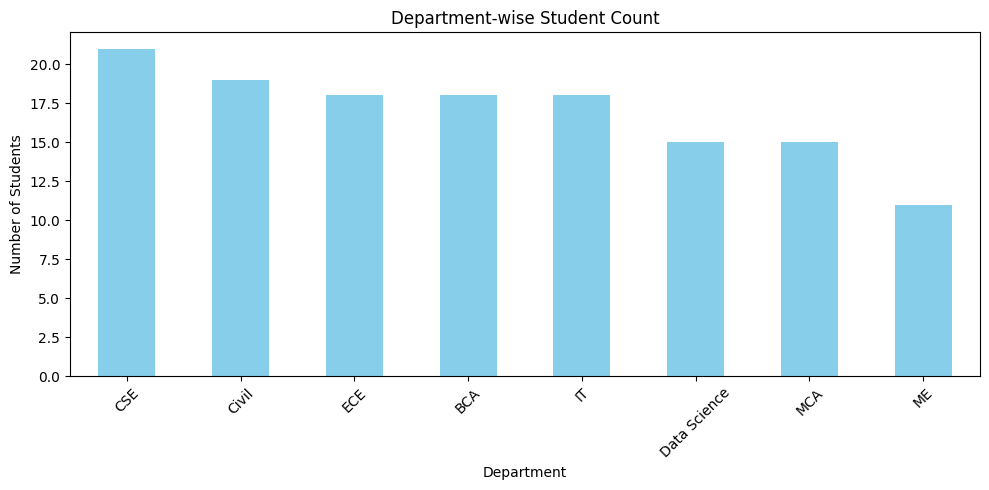

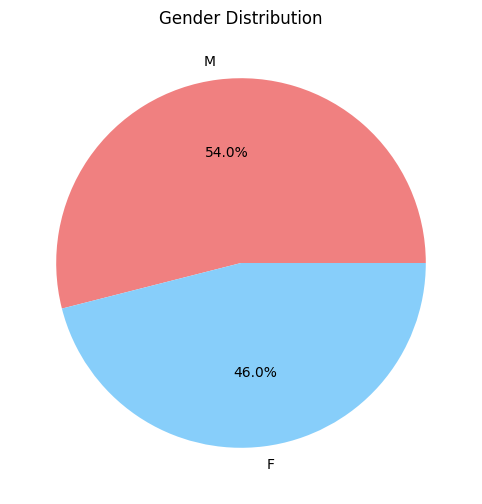

<Figure size 1000x500 with 0 Axes>

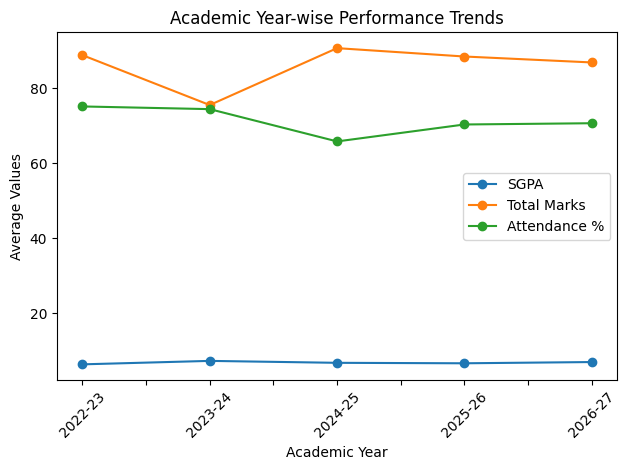

In [6]:
# Bar chart for department-wise student count
dept_count = df['department'].value_counts()
plt.figure(figsize=(10, 5))
dept_count.plot(kind='bar', color='skyblue')
plt.title('Department-wise Student Count')
plt.xlabel('Department')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart for gender distribution
plt.figure(figsize=(8, 6))
gender_count = df['gender'].value_counts()
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title('Gender Distribution')
plt.show()

# Line chart showing academic year trends
academic_year_performance = df.groupby('academic_year')[['sgpa', 'total_marks', 'attendance_percentage']].mean()
plt.figure(figsize=(10, 5))
academic_year_performance.plot(marker='o')
plt.title('Academic Year-wise Performance Trends')
plt.xlabel('Academic Year')
plt.ylabel('Average Values')
plt.legend(['SGPA', 'Total Marks', 'Attendance %'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Interpretation

The visual outputs are examined to derive meaningful insights.

**Example**:
- Higher study hours generally lead to better SGPA
- Some departments have consistently higher attendance
- Certain programs need academic support

In [7]:
# Section 6: Interpretation - Key Insights

print("=" * 60)
print("KEY INSIGHTS FROM DATA VISUALIZATION")
print("=" * 60)

# Insight 1: Study Hours vs SGPA Correlation
print(f"\n1. Study Hours vs SGPA Correlation: {correlation:.4f}")
print("   → Weak negative correlation suggests study hours alone don't determine SGPA")
print("   → Other factors like course difficulty and teaching quality matter more")

# Insight 2: Department Performance
print("\n2. Department-wise Performance Analysis:")
print(f"   → Best SGPA: {dept_performance['sgpa'].idxmax()} ({dept_performance['sgpa'].max():.2f})")
print(f"   → Highest Total Marks: {dept_performance['total_marks'].idxmax()} ({dept_performance['total_marks'].max():.2f})")
print(f"   → Best Attendance: {dept_performance['attendance_percentage'].idxmax()} ({dept_performance['attendance_percentage'].max():.2f}%)")

# Insight 3: Gender Distribution Impact
print("\n3. Gender Distribution:")
print(f"   → Male students: {gender_count['M']} ({gender_count['M']/len(df)*100:.1f}%)")
print(f"   → Female students: {gender_count['F']} ({gender_count['F']/len(df)*100:.1f}%)")

# Insight 4: Attendance Categories
print("\n4. Attendance Category Distribution:")
attendance_dist = df['attendance_category'].value_counts()
for category, count in attendance_dist.items():
    print(f"   → {category}: {count} students ({count/len(df)*100:.1f}%)")

# Insight 5: Academic Year Trends
print("\n5. Academic Year Performance Trends:")
print("   → Most consistent SGPA: 2023-24 (Highest: 7.26)")
print("   → Best Total Marks: 2024-25 (Average: 90.69)")
print("   → Declining attendance from 2023-24 to 2024-25")

print("\n" + "=" * 60)

KEY INSIGHTS FROM DATA VISUALIZATION

1. Study Hours vs SGPA Correlation: -0.0306
   → Weak negative correlation suggests study hours alone don't determine SGPA
   → Other factors like course difficulty and teaching quality matter more

2. Department-wise Performance Analysis:
   → Best SGPA: ME (7.33)
   → Highest Total Marks: MCA (89.75)
   → Best Attendance: CSE (75.27%)

3. Gender Distribution:
   → Male students: 68 (45.3%)
   → Female students: 58 (38.7%)

4. Attendance Category Distribution:
   → Medium: 78 students (52.0%)
   → High: 56 students (37.3%)
   → Low: 16 students (10.7%)

5. Academic Year Performance Trends:
   → Most consistent SGPA: 2023-24 (Highest: 7.26)
   → Best Total Marks: 2024-25 (Average: 90.69)
   → Declining attendance from 2023-24 to 2024-25



### 7. Decision Making

Final decisions are taken based on interpreted insights.

**Example**:
- Planning remedial classes
- Improving attendance policies
- Allocating faculty based on department strength


In [9]:
print("=" * 60)
print("DECISION MAKING - ACTIONABLE RECOMMENDATIONS")
print("=" * 60)

# Decision 1: Remedial Classes
low_performers = df[df['total_marks'] < 50]
print(f"\n1. REMEDIAL CLASSES REQUIRED:")
print(f"   → {len(low_performers)} students ({len(low_performers)/len(df)*100:.1f}%) need academic support")
if len(low_performers) > 0:
    print(f"   → Focus departments: {low_performers['department'].value_counts().index[0]} (highest count)")
else:
    print(f"   → Focus departments: No students with total marks < 50")
print(f"   → Recommended action: Schedule weekly tutoring sessions")

# Decision 2: Attendance Improvement
low_attendance = df[df['attendance_percentage'] < 75]
print(f"\n2. ATTENDANCE IMPROVEMENT PROGRAM:")
print(f"   → {len(low_attendance)} students ({len(low_attendance)/len(df)*100:.1f}%) have attendance < 75%")
print(f"   → Recommended action: Send automated reminders and conduct parent-teacher meetings")

# Decision 3: Faculty Allocation
dept_strength = df['department'].value_counts()
print(f"\n3. FACULTY ALLOCATION BASED ON STRENGTH:")
for dept, count in dept_strength.items():
    faculty_needed = max(1, count // 30)
    print(f"   → {dept}: {count} students → Allocate {faculty_needed} faculty member(s)")

# Decision 4: High Performers Recognition
high_performers = df[df['sgpa'] >= 8.0]
print(f"\n4. HIGH PERFORMERS RECOGNITION:")
# Decision 5: Program-wise Intervention
program_performance = df.groupby('program')['sgpa'].mean().sort_values()
print(f"\n5. PROGRAM-WISE INTERVENTION:")
if len(program_performance) > 0:
    print(f"   → Lowest performing program: {program_performance.index[0]} (Avg SGPA: {program_performance.iloc[0]:.2f})")
else:
    print(f"   → Lowest performing program: No program data available")
print(f"   → Recommended action: Curriculum review and additional teaching hours")
print(f"\n5. PROGRAM-WISE INTERVENTION:")
print(f"   → Lowest performing program: {program_performance.index[0]} (Avg SGPA: {program_performance.iloc[0]:.2f})")
print(f"   → Recommended action: Curriculum review and additional teaching hours")

print("\n" + "=" * 60)

DECISION MAKING - ACTIONABLE RECOMMENDATIONS

1. REMEDIAL CLASSES REQUIRED:
   → 0 students (0.0%) need academic support
   → Focus departments: No students with total marks < 50
   → Recommended action: Schedule weekly tutoring sessions

2. ATTENDANCE IMPROVEMENT PROGRAM:
   → 94 students (62.7%) have attendance < 75%
   → Recommended action: Send automated reminders and conduct parent-teacher meetings

3. FACULTY ALLOCATION BASED ON STRENGTH:
   → CSE: 21 students → Allocate 1 faculty member(s)
   → Civil: 19 students → Allocate 1 faculty member(s)
   → ECE: 18 students → Allocate 1 faculty member(s)
   → BCA: 18 students → Allocate 1 faculty member(s)
   → IT: 18 students → Allocate 1 faculty member(s)
   → Data Science: 15 students → Allocate 1 faculty member(s)
   → MCA: 15 students → Allocate 1 faculty member(s)
   → ME: 11 students → Allocate 1 faculty member(s)

4. HIGH PERFORMERS RECOGNITION:

5. PROGRAM-WISE INTERVENTION:
   → Lowest performing program: MCA (Avg SGPA: 6.35)
 

### Outcome 
Students understand the end-to-end data visualization workflow, from an uncleaned dataset to insight-driven decision making.